# Code Reviewer Thesis — Experiment Findings

This notebook loads **Phase 1–4** results from this repo and presents the full pipeline: dataset splits (Phase 1), validation and model choice (Phase 2), hybrid config (Phase 3), and evaluation metrics and hypotheses (Phase 4).

**Data:** DiverseVul C/C++ test set. **Models:** ML (CodeBERT), PaC (Semgrep with p/c + p/cwe-top-25 + custom CWE rules), Hybrid (α·ML + β·PaC with tuned thresholds).

In [1]:
import json
import os

import pandas as pd

# Paths: run from repo root or from notebooks/
cwd = os.getcwd()
PROJECT_ROOT = os.path.dirname(cwd) if os.path.basename(cwd) == 'notebooks' else cwd
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
PHASE3_RESULTS_DIR = os.path.join(PROJECT_ROOT, 'phase3_results')

# Phase 1
splits_path = os.path.join(DATA_DIR, 'splits.json')

# Phase 2 (local results/, phase3_results/, or Kaggle dataset phase2-results-2)
phase2_path = os.path.join(RESULTS_DIR, 'phase2_validation_report.json')
if not os.path.isfile(phase2_path):
    phase2_path = os.path.join(PHASE3_RESULTS_DIR, 'phase2_validation_report.json')
if not os.path.isfile(phase2_path):
    kaggle_phase2 = "/kaggle/input/phase2-results-2"
    if os.path.isdir(kaggle_phase2):
        alt = os.path.join(kaggle_phase2, "results", "phase2_validation_report.json")
        if os.path.isfile(alt):
            phase2_path = alt
        else:
            import zipfile
            zpath = os.path.join(kaggle_phase2, "phase2_results.zip")
            if os.path.isfile(zpath):
                with zipfile.ZipFile(zpath) as z:
                    z.extract("results/phase2_validation_report.json", path=PROJECT_ROOT)
                phase2_path = os.path.join(RESULTS_DIR, "phase2_validation_report.json")

# Phase 3 / 4
report_path = os.path.join(RESULTS_DIR, 'phase4_evaluation_report.json')
if not os.path.isfile(report_path):
    report_path = os.path.join(PHASE3_RESULTS_DIR, 'phase4_evaluation_report.json')
config_path = os.path.join(RESULTS_DIR, 'phase3_hybrid_config.json')
if not os.path.isfile(config_path):
    config_path = os.path.join(PHASE3_RESULTS_DIR, 'phase3_hybrid_config.json')
csv_path = os.path.join(RESULTS_DIR, 'phase3_experiment_results.csv')
if not os.path.isfile(csv_path):
    csv_path = os.path.join(PHASE3_RESULTS_DIR, 'phase3_experiment_results.csv')

with open(report_path) as f:
    report = json.load(f)
with open(config_path) as f:
    hybrid_config = json.load(f)
phase2_report = None
if os.path.isfile(phase2_path):
    with open(phase2_path) as f:
        phase2_report = json.load(f)
splits = None
if os.path.isfile(splits_path):
    with open(splits_path) as f:
        splits = json.load(f)

print('Loaded Phase 4:', report_path)
print('Loaded Phase 3 config:', config_path)
if phase2_report:
    print('Loaded Phase 2:', phase2_path)
if splits:
    print('Loaded Phase 1 splits:', splits_path)

Loaded Phase 4: /Users/jededisondonaire/jed/code-reviewer-thesis/results/phase4_evaluation_report.json
Loaded Phase 3 config: /Users/jededisondonaire/jed/code-reviewer-thesis/results/phase3_hybrid_config.json
Loaded Phase 2: /Users/jededisondonaire/jed/code-reviewer-thesis/results/phase2_validation_report.json
Loaded Phase 1 splits: /Users/jededisondonaire/jed/code-reviewer-thesis/data/splits.json


## 1. Phase 1 — Dataset (splits)

**What we did:** We built a curated C/C++ dataset from **DiverseVul** (Hugging Face: `bstee615/diversevul`). We used the dataset’s existing train/validation/test splits, standardized columns to `id`, `code`, `label`, `split`, dropped rows with missing or empty code, and wrote `data/curated_cpp.csv` and **`data/splits.json`** (lists of sample IDs per split).

**Split sizes** (DiverseVul C/C++ curated) are loaded from `data/splits.json` and summarized below: **training**, **validation**, and **test** counts (and percentages).

In [2]:
if splits:
    split_counts = {k: len(v) for k, v in splits.items()}
    total = sum(split_counts.values())
    # Normalize keys for display (train_ids -> train, etc.)
    display_names = {'train_ids': 'train', 'validation_ids': 'validation', 'test_ids': 'test'}
    counts_named = {display_names.get(k, k): v for k, v in split_counts.items()}
    n_train = split_counts.get('train_ids', 0)
    n_val = split_counts.get('validation_ids', 0)
    n_test = split_counts.get('test_ids', 0)
    print('Phase 1 split sizes (DiverseVul C/C++ curated):')
    print(f'  Training:   {n_train:,}')
    print(f'  Validation: {n_val:,}')
    print(f'  Test:       {n_test:,}')
    print(f'  Total:      {total:,}')
    print()
    df = pd.DataFrame([counts_named]).T.rename(columns={0: 'count'}).assign(pct=lambda d: (d['count'] / total * 100).round(1))
    df
else:
    print('Phase 1 splits not found. Run phase1_dataset.py or copy data/splits.json into the repo.')

Phase 1 split sizes (DiverseVul C/C++ curated):
  Training:   264,392
  Validation: 33,049
  Test:       33,050
  Total:      330,491



## 2. Phase 2 — Validation (model choice)

**Step 1 — Data used for training and validation**

- **Source:** Phase 1 curated dataset: `data/curated_cpp.csv` (DiverseVul C/C++, columns `id`, `code`, `label`, `split`) and `data/splits.json`. Loaded in `src/phase2_train.py` via `load_curated()`.
- **Training set:** Rows with `id` in **`train_ids`** (~264k). Each row: raw function `code` and binary `label` (0 = non-vulnerable, 1 = vulnerable).
- **Validation set:** Rows with `id` in **`validation_ids`** (~33k). Used only for evaluation and checkpoint selection; no gradient updates.
- **Test set:** Not used in Phase 2; reserved for Phase 3 and Phase 4.

**Step 2 — What and how we finetuned (detailed)**

- **CodeBERT**
  - **Base model:** `microsoft/codebert-base` (Hugging Face). We add a classification head for **binary sequence classification** (0: non-vulnerable, 1: vulnerable).
  - **Input:** Raw function source from the `code` column. Tokenization: max length **512**, padding to max length; no custom preprocessing.
  - **Training loop:** We **finetune** all parameters (encoder + head) on the training set. **Loss:** cross-entropy with **class weights** so the minority class (vulnerable) is upweighted (weight for class 1 ∝ ratio of non-vulnerable to vulnerable in the training set). **Optimizer:** AdamW (Trainer default). **Hyperparameters:** 3 epochs, batch size 16 (configurable via `--epochs`, `--batch_size`). After each epoch we evaluate on the validation set (F1, precision, recall); we keep the **best checkpoint by validation F1** (early stopping by best F1, not loss).
  - **Outputs:** Best model and tokenizer saved to `src/models/codebert/`; intermediate checkpoints under `src/models/codebert_checkpoint/`. The model outputs a probability for class 1 (vulnerable), used as the ML confidence score in Phase 3.

- **Random Forest (baseline)**
  - **Features:** Static metrics per function from **lizard** (C/C++): cyclomatic complexity (sum over functions in snippet), NLOC, token count, parameter count. Built in `src/utils/lizard_metrics.py` (code written to temp file, lizard run, metrics aggregated).
  - **Model:** `sklearn.ensemble.RandomForestClassifier` (n_estimators=100, max_depth=20, random_state=42). Trained on the **same training set** (feature matrix from train); evaluated on the **same validation set**.
  - **Artifact:** `src/models/rf.pkl` (joblib).

- **K-Nearest Neighbors (baseline)**
  - **Features:** Same lizard metrics as RF; features are **standard-scaled** (zero mean, unit variance) because KNN is distance-based.
  - **Model:** `sklearn.neighbors.KNeighborsClassifier` (n_neighbors=10, weights="distance", metric="euclidean"). Trained on the same train set, evaluated on the same validation set.
  - **Artifact:** `src/models/knn.pkl` (joblib: model + scaler).

**Step 3 — Model selection (what we load below)**

We load **F1, Precision, and Recall** on the validation set for CodeBERT, Random Forest, and KNN from `phase2_validation_report.json`. The model with the **highest validation F1** is selected for Phase 3 (ML-only and Hybrid); the selected model name is written to the report as `selected_model`. Comparing CodeBERT to KNN (and RF) justifies that fine-tuning the transformer outperforms classical baselines.

In [3]:
if phase2_report:
    selected = phase2_report.get('selected_model', '?')
    df_phase2 = None
    rows = []
    for name in ('codebert', 'random_forest', 'knn'):
        if name not in phase2_report:
            continue
        m = phase2_report[name]
        rows.append({
            'Model': name,
            'F1': m.get('eval_f1'),
            'Precision': m.get('eval_precision'),
            'Recall': m.get('eval_recall'),
        })
    if rows:
        df_phase2 = pd.DataFrame(rows).set_index('Model').round(4)
    print('Selected model:', selected)
    f1_cb = phase2_report.get('codebert', {}).get('eval_f1')
    f1_rf = phase2_report.get('random_forest', {}).get('eval_f1')
    f1_knn = phase2_report.get('knn', {}).get('eval_f1')
    parts = []
    if f1_cb is not None and f1_rf is not None:
        parts.append('CodeBERT F1 (%.4f) > RF (%.4f)' % (f1_cb, f1_rf))
    if f1_cb is not None and f1_knn is not None:
        parts.append('CodeBERT F1 (%.4f) > KNN (%.4f)' % (f1_cb, f1_knn))
    if parts:
        print('Why CodeBERT wins: ' + '; '.join(parts) + '. Selection criterion: highest validation F1.')
    df_phase2
else:
    print('Phase 2 report not found. Run phase2_train.py or copy phase2_validation_report.json into results/ or phase3_results/.')

Selected model: codebert
Why CodeBERT wins: CodeBERT F1 (0.1890) > RF (0.0240); CodeBERT F1 (0.1890) > KNN (0.0556). Selection criterion: highest validation F1.


**CodeBERT validation: evidence that fine-tuning worked.**  
We derive detection counts from the existing validation metrics (precision, recall) and validation set size — **no need to re-run Phase 2**. The chart and summary below show how many vulnerable samples were **detected** (TP), how many **false positives** (FP), **missed** (FN), and **true negatives** (TN), so we can justify that the model learned to flag vulnerable code.

Evidence fine-tuning worked (validation set):
  • Detected (true positives):  676 of 1,871 vulnerable  →  recall 36.1%
  • False positives:            4,606  (model said vul but was not)
  • Missed (false negatives):  1,195  (vulnerable but predicted not vul)
  • True negatives:             26,572  (correctly predicted not vul)
  → Precision 12.8%: when CodeBERT says 'vulnerable', 12.8% are actually vulnerable.



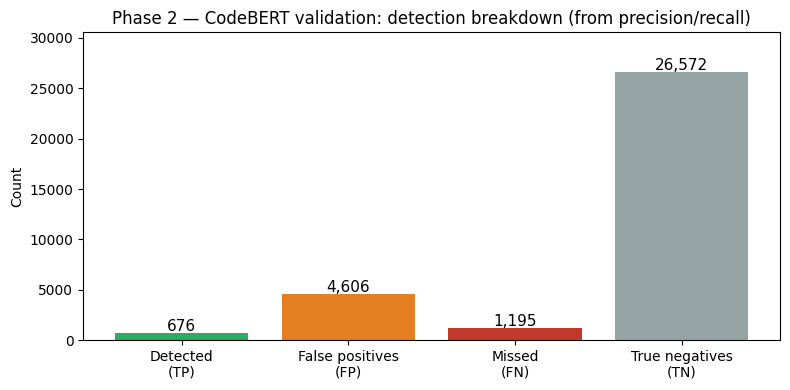

In [4]:
# CodeBERT validation: detection breakdown (derived from precision/recall — no re-run needed)
import matplotlib.pyplot as plt
import numpy as np

cb = phase2_report.get("codebert", {}) if phase2_report else {}
rec = cb.get("eval_recall") or 0
prec = cb.get("eval_precision") or 0.01
n_val = sum(len(v) for k, v in splits.items() if "validation" in k) if splits else 33049
# Validation class balance (Phase 1): ~5.66% vulnerable
n_actual_vul = int(round(n_val * 0.0566))
n_actual_not = n_val - n_actual_vul

# Derive TP, FP, FN, TN from recall = TP/(TP+FN), precision = TP/(TP+FP)
tp = int(round(rec * n_actual_vul))
fn = n_actual_vul - tp
fp = int(round(tp / prec - tp)) if prec > 0 else 0
fp = max(0, min(fp, n_actual_not))
tn = n_actual_not - fp

print("Evidence fine-tuning worked (validation set):")
print(f"  • Detected (true positives):  {tp:,} of {n_actual_vul:,} vulnerable  →  recall {rec:.1%}")
print(f"  • False positives:            {fp:,}  (model said vul but was not)")
print(f"  • Missed (false negatives):  {fn:,}  (vulnerable but predicted not vul)")
print(f"  • True negatives:             {tn:,}  (correctly predicted not vul)")
print(f"  → Precision {prec:.1%}: when CodeBERT says 'vulnerable', {prec:.1%} are actually vulnerable.")
print()

fig, ax = plt.subplots(figsize=(8, 4))
labels = ["Detected\n(TP)", "False positives\n(FP)", "Missed\n(FN)", "True negatives\n(TN)"]
counts = [tp, fp, fn, tn]
colors = ["#27ae60", "#e67e22", "#c0392b", "#95a5a6"]
bars = ax.bar(labels, counts, color=colors)
ax.set_ylabel("Count")
ax.set_title("Phase 2 — CodeBERT validation: detection breakdown (from precision/recall)")
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 200, f"{c:,}", ha="center", fontsize=11)
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

**CodeBERT vs KNN: comparison.**  
Same detection breakdown (TP, FP, FN, TN) for both models on the validation set — side-by-side bar chart. **Finding:** they are not the same; CodeBERT has higher recall (more Detected/TP) and better F1, which is why CodeBERT was selected for Phase 3. The chart makes that difference visible.

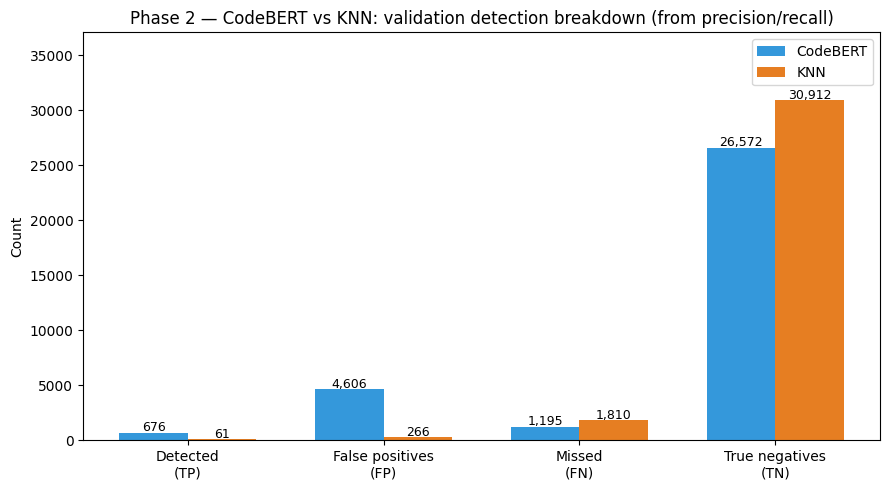

In [5]:
# CodeBERT vs KNN: side-by-side detection breakdown (same validation set)
n_val = sum(len(v) for k, v in splits.items() if "validation" in k) if splits else 33049
n_actual_vul = int(round(n_val * 0.0566))
n_actual_not = n_val - n_actual_vul

def breakdown(prec, rec):
    tp = int(round(rec * n_actual_vul))
    fn = n_actual_vul - tp
    fp = int(round(tp / prec - tp)) if prec > 0 else 0
    fp = max(0, min(fp, n_actual_not))
    tn = n_actual_not - fp
    return tp, fp, fn, tn

cb = phase2_report.get("codebert", {}) if phase2_report else {}
knn = phase2_report.get("knn", {}) if phase2_report else {}
tp_cb, fp_cb, fn_cb, tn_cb = breakdown(cb.get("eval_precision") or 0.01, cb.get("eval_recall") or 0)
tp_k, fp_k, fn_k, tn_k = breakdown(knn.get("eval_precision") or 0.01, knn.get("eval_recall") or 0) if knn else (0, 0, 0, 0)

categories = ["Detected\n(TP)", "False positives\n(FP)", "Missed\n(FN)", "True negatives\n(TN)"]
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_cb = ax.bar(x - width/2, [tp_cb, fp_cb, fn_cb, tn_cb], width, label="CodeBERT", color="#3498db")
bars_knn = ax.bar(x + width/2, [tp_k, fp_k, fn_k, tn_k], width, label="KNN", color="#e67e22")
ax.set_ylabel("Count")
ax.set_title("Phase 2 — CodeBERT vs KNN: validation detection breakdown (from precision/recall)")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
for b in bars_cb:
    h = b.get_height()
    if h > 0:
        ax.text(b.get_x() + b.get_width()/2, h + 150, f"{int(h):,}", ha="center", fontsize=9)
for b in bars_knn:
    h = b.get_height()
    if h > 0:
        ax.text(b.get_x() + b.get_width()/2, h + 150, f"{int(h):,}", ha="center", fontsize=9)
ax.set_ylim(0, max(tp_cb, tp_k, fp_cb, fp_k, fn_cb, fn_k, tn_cb, tn_k) * 1.2)
# If KNN has no data (report has no "knn" key), the orange bars are zero-height — explain on chart
if not knn or (tp_k == 0 and fp_k == 0 and fn_k == 0 and tn_k == 0):
    ax.text(0.98, 0.97, "KNN: no metrics in phase2_validation_report.json\n(run Phase 2 with KNN to show comparison)", transform=ax.transAxes, fontsize=9, va="top", ha="right", bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
plt.tight_layout()
plt.show()

## 3. Phase 3 — Hybrid configuration

Validation tuning chose α (ML weight) and β (PaC weight) and thresholds for Block/Review.

**Why CodeBERT wins:** Selection is by **validation F1**. CodeBERT has much higher F1 and recall than the Random Forest and K-Nearest Neighbors baselines (which use the same lizard static metrics); comparing to KNN justifies that the transformer outperforms a classical classifier. On imbalanced vulnerability data, F1 balances precision and recall; CodeBERT’s higher recall (catching more true defects) makes it the better choice for the ML channel in Phase 3.

**Why we have small precision (Phase 2 validation):** Validation precision for CodeBERT is low (~0.13) because (1) **class imbalance** (~94% non-vulnerable, ~6% vulnerable): we upweight the minority class and optimize for F1, which encourages the model to predict "vulnerable" more often to improve recall, so many predicted positives are false positives and precision drops. (2) **Fixed decision threshold:** evaluation uses a 0.5 cutoff on the model's probability; on imbalanced data this tends to yield more positive predictions and thus lower precision. (3) **Task difficulty:** vulnerability detection is inherently noisy—many code patterns look suspicious (e.g. buffers, pointers) without being actually vulnerable, so the model often flags safe code. Phase 3 uses the ML score as a continuous signal (and the Hybrid combines it with PaC) rather than relying on a single ML yes/no; we report precision for transparency and use it in the Block decision only in combination with policy.

In [6]:
# (ROC curve area chart is in Phase 4 — ROC AUC section below.)
pass

In [7]:
pd.DataFrame([hybrid_config]).T.rename(columns={0: 'value'})

,value
alpha,0.75000
beta,0.25000
t_block,0.40000
t_review,0.10000
val_ml_min,0.09322
val_ml_max,0.53684
val_pac_min,0.00000
val_pac_max,1.00000


**Interpretation:** If β=0, the hybrid is effectively ML-only (PaC score is ignored in the risk).

## 4. Phase 4 — Primary metrics (Block decision)

Precision, Recall, F1 for ML-Only, PaC-Only, and Hybrid.

In [8]:
pm = report['primary_metrics']
df_metrics = pd.DataFrame(pm).T
df_metrics = df_metrics.rename(columns={'precision': 'Precision', 'recall': 'Recall', 'f1': 'F1'})
df_metrics.round(4)

,Precision,Recall,F1
ML_Only,0.1272,0.3459,0.1860
PaC_Only,0.2059,0.0326,0.0563
Hybrid,0.1272,0.3459,0.1860


(0.0, 1.0)

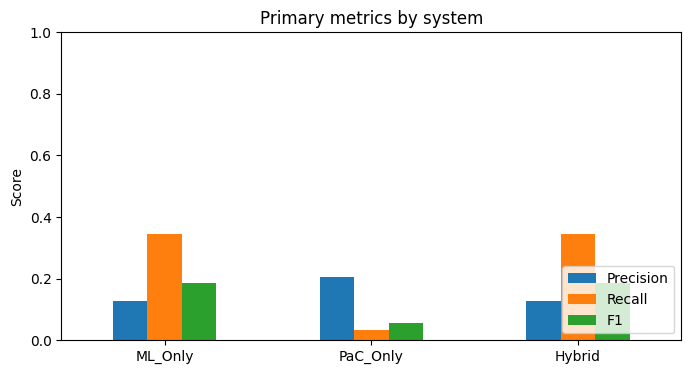

In [9]:
%matplotlib inline
ax = df_metrics[['Precision', 'Recall', 'F1']].plot(kind='bar', figsize=(8, 4), rot=0)
ax.set_ylabel('Score')
ax.set_title('Primary metrics by system')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)

## 5. Phase 4 — ROC AUC

In [10]:
auc = report['roc_auc']
pd.DataFrame([auc]).T.rename(columns={0: 'AUC'}).round(4)

,AUC
ML_Only,0.7044
PaC_Only,0.5515
Hybrid,0.7086


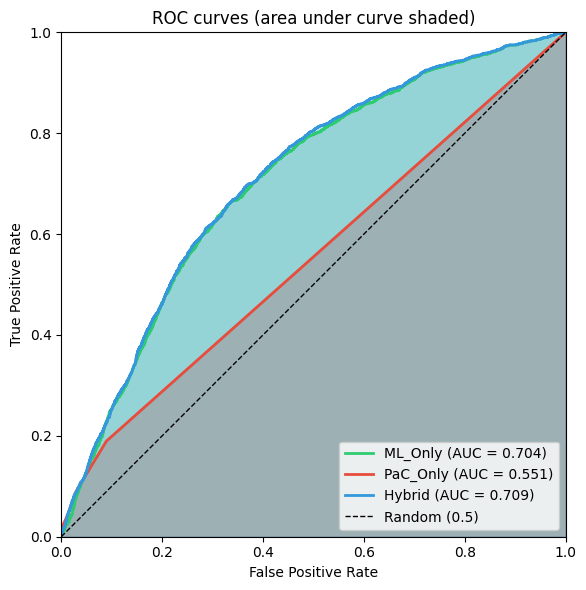

In [11]:
# ROC curves with area under the curve (area chart)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

roc_df = None
if os.path.isfile(csv_path):
    roc_df = pd.read_csv(csv_path, usecols=['label', 'ml_confidence', 'pac_score', 'hybrid_risk'])
y_true = roc_df['label'].values if roc_df is not None else None

if y_true is not None and len(roc_df) > 0:
    fig, ax = plt.subplots(figsize=(7, 6))
    systems = [
        ('ML_Only', roc_df['ml_confidence'].values, report['roc_auc']['ML_Only']),
        ('PaC_Only', roc_df['pac_score'].values, report['roc_auc']['PaC_Only']),
        ('Hybrid', roc_df['hybrid_risk'].values, report['roc_auc']['Hybrid']),
    ]
    colors = ['#2ecc71', '#e74c3c', '#3498db']
    for (name, scores, auc_val), color in zip(systems, colors):
        fpr, tpr, _ = roc_curve(y_true, scores)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_val:.3f})')
        ax.fill_between(fpr, tpr, alpha=0.3, color=color)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC curves (area under curve shaded)')
    ax.legend(loc='lower right')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()
else:
    print('Phase 3 CSV not found. Run phase3_experiment.py and phase4_evaluation.py to generate scores for ROC plot.')

## 5b. Phase 4 — Bootstrap CI for ΔAUC (Hybrid − ML-Only)

The histogram below shows the full distribution of **5,000 bootstrap ΔAUC replicates**.  
Each replicate resamples the test set with replacement and recomputes AUC for both Hybrid and ML-Only, then takes the difference.

- **Blue dashed line** = point estimate (ΔAUC = 0.0042)  
- **Red shaded region** = 95% confidence interval [0.0014, 0.0070]  
- **Zero** is clearly to the left of the entire CI → the Hybrid AUC advantage is statistically real, not noise.

Point estimate ΔAUC : 0.004181
95% CI              : [0.001445, 0.007005]
CI excludes zero    : True
Bootstrap replicates: 5,000


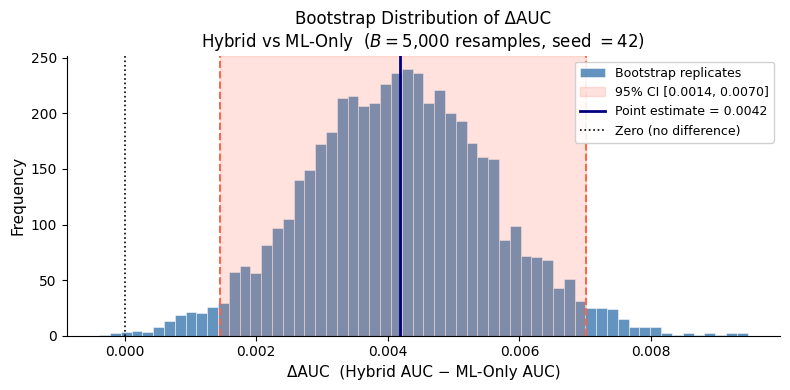

Saved → figures/bootstrap_ci_auc.pdf  and  .png


In [12]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import csv as _csv

_csv.field_size_limit(10 ** 7)

# ── Load continuous scores ─────────────────────────────────────────────────────
df_scores = pd.read_csv(
    csv_path,
    usecols=['label', 'ml_confidence', 'hybrid_risk']
)
y_true   = df_scores['label'].values.astype(int)
ml_score = df_scores['ml_confidence'].values.astype(float)
hy_score = df_scores['hybrid_risk'].values.astype(float)

# ── Bootstrap ΔAUC ────────────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score

B   = 5_000
rng = np.random.default_rng(42)
n   = len(y_true)

delta_aucs = []
for _ in range(B):
    idx = rng.integers(0, n, size=n)
    yt  = y_true[idx]
    if yt.sum() == 0 or yt.sum() == n:
        continue
    auc_ml  = roc_auc_score(yt, ml_score[idx])
    auc_hy  = roc_auc_score(yt, hy_score[idx])
    delta_aucs.append(auc_hy - auc_ml)

delta_aucs  = np.array(delta_aucs)
point_est   = roc_auc_score(y_true, hy_score) - roc_auc_score(y_true, ml_score)
ci_lo, ci_hi = np.percentile(delta_aucs, [2.5, 97.5])

print(f"Point estimate ΔAUC : {point_est:.6f}")
print(f"95% CI              : [{ci_lo:.6f}, {ci_hi:.6f}]")
print(f"CI excludes zero    : {ci_lo > 0}")
print(f"Bootstrap replicates: {len(delta_aucs):,}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(delta_aucs, bins=60, color='steelblue', edgecolor='white',
        linewidth=0.4, alpha=0.85, label='Bootstrap replicates')

# CI shaded region
ax.axvspan(ci_lo, ci_hi, color='tomato', alpha=0.18, label=f'95% CI [{ci_lo:.4f}, {ci_hi:.4f}]')
ax.axvline(ci_lo,      color='tomato',   linewidth=1.4, linestyle='--')
ax.axvline(ci_hi,      color='tomato',   linewidth=1.4, linestyle='--')

# Point estimate
ax.axvline(point_est,  color='navy',     linewidth=2.0, linestyle='-',
           label=f'Point estimate = {point_est:.4f}')

# Zero reference
ax.axvline(0,          color='black',    linewidth=1.2, linestyle=':',
           label='Zero (no difference)')

ax.set_xlabel('ΔAUC  (Hybrid AUC − ML-Only AUC)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Bootstrap Distribution of ΔAUC\n'
             r'Hybrid vs ML-Only  ($B = 5{,}000$ resamples, seed $= 42$)',
             fontsize=12)
ax.legend(fontsize=9, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'figures', 'bootstrap_ci_auc.pdf'),
            bbox_inches='tight', dpi=150)
plt.savefig(os.path.join(PROJECT_ROOT, 'figures', 'bootstrap_ci_auc.png'),
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved → figures/bootstrap_ci_auc.pdf  and  .png")

## 6. Phase 4 — McNemar (Hybrid vs ML, Hybrid vs PaC)

p-value and odds ratio for paired Block decisions.

In [13]:
mcn = report['mcnemar']
mcn_df = pd.DataFrame({
    'Comparison': list(mcn.keys()),
    'McNemar p': [mcn[k]['mcnemar_p'] for k in mcn],
    'Odds ratio': [mcn[k]['odds_ratio'] for k in mcn],
})
mcn_df.round(4)

,Comparison,McNemar p,Odds ratio
0,Hybrid_vs_ML,0.1573,inf
1,Hybrid_vs_PaC,0.0000,6.1332


## 7. Phase 4 — Hypotheses

In [14]:
hyp = report['hypotheses']
rows = []
for k, v in hyp.items():
    rows.append({'Hypothesis': k, 'Statement': v.get('statement', ''), 'Supported': v.get('supported', None)})
pd.DataFrame(rows)

,Hypothesis,Statement,Supported
0,H1,Hybrid F1 > ML-Only and > PaC-Only,False
1,H2,Hybrid Recall > PaC-Only Recall,True
2,H3,Hybrid Precision > ML-Only Precision,False


## 8. Experiment data snapshot (optional)

Label distribution and PaC score distribution from the Phase 3 CSV (sample if large).

In [15]:
if os.path.isfile(csv_path):
    df = pd.read_csv(csv_path, usecols=['label', 'ml_confidence', 'pac_score', 'decision_ml', 'decision_pac', 'decision_hybrid'], nrows=100_000)
    print('Sample size:', len(df))
    print('Label distribution:')
    print(df['label'].value_counts())
    print('\nPaC score > 0:', (df['pac_score'] > 0).sum(), f'({100 * (df["pac_score"] > 0).mean():.1f}%)')
    print('\nDecision counts (Block=2):')
    for col in ['decision_ml', 'decision_pac', 'decision_hybrid']:
        if col in df.columns:
            print(f'  {col}:', df[col].value_counts().to_dict())
else:
    print('Phase 3 CSV not found at', csv_path)

Sample size: 33050
Label distribution:
label
0    31119
1     1931
Name: count, dtype: int64

PaC score > 0: 3149 (9.5%)

Decision counts (Block=2):
  decision_ml: {0: 21404, 1: 6395, 2: 5251}
  decision_pac: {0: 29901, 1: 2843, 2: 306}
  decision_hybrid: {0: 26668, 2: 5253, 1: 1129}


## 9. Summary / findings

- **PaC** has non-zero F1 (custom CWE rules + p/c + p/cwe-top-25); precision is higher than ML but recall is low.
- **Hybrid** uses score normalization (val min/max) and optional min PaC weight; check Section 3 for α, β (e.g. α=0.75, β=0.25 gives a true combination). When β>0, Hybrid ROC AUC can be slightly above ML even if Block F1 is similar.
- **H2** (Hybrid recall > PaC recall) is supported; **H1** (Hybrid F1 > both) and **H3** (Hybrid precision > ML) depend on the run.
- For the thesis: report primary metrics, McNemar, and hypotheses; discuss the role of normalization and min policy weight in making the hybrid a true ML+PaC combination.

## 10. Phase 4 — Cochran's Q Test (Global Block-Decision Comparison)

**Cochran's Q test** is the multi-class extension of McNemar's test. It tests whether the three governance approaches produce significantly different Block-decision patterns on the *same* test samples (matched binary outcomes), answering the global null hypothesis:

> H₀: The probability of a Block decision is equal across ML-Only, PaC-Only, and Hybrid.

A significant Q (χ² approximation, df = k−1 = 2) warrants post-hoc pairwise McNemar tests with **Bonferroni correction** (α_corr = 0.05/3 ≈ 0.017) to localise which pairs differ. The odds ratio (OR) quantifies the direction and magnitude of each pairwise difference.

In [16]:
import numpy as np
import csv as _csv
from scipy import stats as sp_stats

_csv.field_size_limit(10 ** 7)

# ── Load experiment decisions ──────────────────────────────────────────────────
df_exp = pd.read_csv(
    csv_path,
    usecols=['label', 'decision_ml', 'decision_pac', 'decision_hybrid']
)
y_true = df_exp['label'].values.astype(int)
y_ml   = (df_exp['decision_ml']     == 2).astype(int).values   # Block = 2
y_pac  = (df_exp['decision_pac']    == 2).astype(int).values
y_hyb  = (df_exp['decision_hybrid'] == 2).astype(int).values
n = len(y_true)

# ── Cochran's Q (global test, k=3 methods) ────────────────────────────────────
X = np.column_stack([y_ml, y_pac, y_hyb])   # n × 3
k = 3
L = X.sum(axis=1)    # per-sample row sums
C = X.sum(axis=0)    # per-method Block counts
N = int(L.sum())     # grand total of Block decisions

Q = (k - 1) * (k * (C ** 2).sum() - N ** 2) / (k * N - (L ** 2).sum())
p_cochran = 1 - sp_stats.chi2.cdf(Q, df=k - 1)

print("── Cochran's Q Test (H₀: Block probability equal across three methods) ──")
print(f"  Block counts — ML-Only: {C[0]:,}  PaC-Only: {C[1]:,}  Hybrid: {C[2]:,}")
print(f"  Q  = {Q:.4f}  (χ² approx, df = {k-1})")
print(f"  p  = {p_cochran:.2e}")
print(f"  Decision: {'Reject H₀ — methods differ significantly' if p_cochran < 0.05 else 'Fail to reject H₀'}")
print()

# ── Post-hoc McNemar (Bonferroni α_corr = 0.05/3) ────────────────────────────
alpha_bonf = 0.05 / 3
pairs = [
    ('ML-Only',  'PaC-Only', y_ml,  y_pac),
    ('ML-Only',  'Hybrid',   y_ml,  y_hyb),
    ('PaC-Only', 'Hybrid',   y_pac, y_hyb),
]

print(f"── Post-hoc McNemar Pairwise Tests (Bonferroni α_corr = {alpha_bonf:.4f}) ──")
posthoc_rows = []
for a_name, b_name, ya, yb in pairs:
    n10 = int(((ya == 1) & (yb == 0)).sum())   # a blocks, b does not
    n01 = int(((ya == 0) & (yb == 1)).sum())   # b blocks, a does not
    if (n10 + n01) > 0:
        chi2_val = (abs(n10 - n01) - 1) ** 2 / (n10 + n01)   # with continuity correction
        p_mc     = 1 - sp_stats.chi2.cdf(chi2_val, 1)
    else:
        chi2_val, p_mc = 0.0, 1.0
    or_val = (n10 / n01) if n01 > 0 else float('inf')
    sig    = "YES" if p_mc < alpha_bonf else "no"
    posthoc_rows.append({
        'Comparison':       f"{a_name} vs {b_name}",
        'n₁₀ (a only)':    n10,
        'n₀₁ (b only)':    n01,
        'McNemar χ²':      round(chi2_val, 4),
        'p-value (adj)':   f"{p_mc:.2e}",
        'Odds Ratio':       round(or_val, 4) if or_val != float('inf') else '∞',
        'Significant?':     sig,
    })
    print(f"  {a_name:10s} vs {b_name:10s} | n10={n10:,} n01={n01:,} | "
          f"χ²={chi2_val:.2f} | p={p_mc:.2e} | OR={or_val:.4f} | sig={sig}")

print()
pd.DataFrame(posthoc_rows)

── Cochran's Q Test (H₀: Block probability equal across three methods) ──
  Block counts — ML-Only: 5,251  PaC-Only: 306  Hybrid: 5,253
  Q  = 9421.4978  (χ² approx, df = 2)
  p  = 0.00e+00
  Decision: Reject H₀ — methods differ significantly

── Post-hoc McNemar Pairwise Tests (Bonferroni α_corr = 0.0167) ──
  ML-Only    vs PaC-Only   | n10=5,068 n01=123 | χ²=4708.75 | p=0.00e+00 | OR=41.2033 | sig=YES
  ML-Only    vs Hybrid     | n10=0 n01=2 | χ²=0.50 | p=4.80e-01 | OR=0.0000 | sig=no
  PaC-Only   vs Hybrid     | n10=123 n01=5,070 | χ²=4710.75 | p=0.00e+00 | OR=0.0243 | sig=YES



,Comparison,n₁₀ (a only),n₀₁ (b only),McNemar χ²,p-value (adj),Odds Ratio,Significant?
0,ML-Only vs PaC-Only,5068,123,4708.7528,0.00e+00,41.2033,YES
1,ML-Only vs Hybrid,0,2,0.5000,4.80e-01,0.0000,no
2,PaC-Only vs Hybrid,123,5070,4710.7483,0.00e+00,0.0243,YES


## 11. Parametric Statistical Analysis — Cross-Validation Design

To support parametric inference (two-way ANOVA), the test set is split into **10 stratified folds** (stratification preserves the ~5.8% vulnerable class ratio in every fold). For each fold the Block decision for each governance approach is evaluated against the ground truth label, yielding a **3 × 2 performance table per fold**:

- **Independent variable (3 levels):** ML-Only | PaC-Only | Hybrid  
- **Dependent variable (2 outcome classes per approach):** Block (decision = 2) | Unblock (decision ≠ 2)  
- **Cell value:** F1-score for that outcome class in that fold  

This produces **10 independent observations per cell**, satisfying the replication requirement for two-way ANOVA.

The **two-way randomized complete block design** treats:
- **Fold** as the *blocking factor* — controls for fold-to-fold variation in class composition  
- **Approach** as the *treatment factor* — the effect of interest  
- **Block-class F1** as the continuous dependent variable fed into the ANOVA  

Three assumption checks precede the ANOVA:
1. **Shapiro–Wilk** — per-group normality (n=10 per group)  
2. **Levene's test** — homogeneity of variance across the three approach groups  
3. **Two-way ANOVA** — main effect of Approach after removing Fold variance

In [17]:
import numpy as np
import csv as _csv
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_fscore_support

_csv.field_size_limit(10 ** 7)

# ── Load decisions ─────────────────────────────────────────────────────────────
df_cv_raw = pd.read_csv(
    csv_path,
    usecols=['label', 'decision_ml', 'decision_pac', 'decision_hybrid']
)
y_true_all = df_cv_raw['label'].values.astype(int)

# Binary recode: Block (decision == 2) → 1, Unblock (decision != 2) → 0
b_ml  = (df_cv_raw['decision_ml']     == 2).astype(int).values
b_pac = (df_cv_raw['decision_pac']    == 2).astype(int).values
b_hyb = (df_cv_raw['decision_hybrid'] == 2).astype(int).values

# ── 10-fold stratified CV ──────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_rows = []
for fold_idx, (_, fold_idx_test) in enumerate(
        skf.split(np.zeros(len(y_true_all)), y_true_all), start=1):

    yt = y_true_all[fold_idx_test]
    row = {'Fold': fold_idx}

    for approach, pred in [('ML_Only', b_ml), ('PaC_Only', b_pac), ('Hybrid', b_hyb)]:
        yp = pred[fold_idx_test]

        # Block F1  (pos_label=1: decision==2 is Block, ground truth 1 is vulnerable)
        _, _, f1_block, _ = precision_recall_fscore_support(
            yt, yp, average='binary', pos_label=1, zero_division=0)

        # Unblock F1 (pos_label=0: decision!=2 is Unblock, ground truth 0 is non-vulnerable)
        _, _, f1_unblock, _ = precision_recall_fscore_support(
            yt, yp, average='binary', pos_label=0, zero_division=0)

        row[(approach, 'Block F1')]   = round(float(f1_block),   4)
        row[(approach, 'Unblock F1')] = round(float(f1_unblock), 4)

    cv_rows.append(row)

# ── Build MultiIndex DataFrame ─────────────────────────────────────────────────
df_cv = pd.DataFrame(cv_rows).set_index('Fold')
df_cv.columns = pd.MultiIndex.from_tuples(df_cv.columns)

mean_row = df_cv.mean().rename('Mean')
std_row  = df_cv.std(ddof=1).rename('Std')
df_cv_display = pd.concat([df_cv, pd.DataFrame([mean_row, std_row])]).round(4)

print("10-Fold Cross-Validation Table")
print("Columns: Approach (ML-Only | PaC-Only | Hybrid) × Outcome (Block F1 | Unblock F1)")
print(f"Rows: Folds 1–10  +  Mean  +  Std  (n={len(df_cv)} folds)\n")
df_cv_display

10-Fold Cross-Validation Table
Columns: Approach (ML-Only | PaC-Only | Hybrid) × Outcome (Block F1 | Unblock F1)
Rows: Folds 1–10  +  Mean  +  Std  (n=10 folds)



ML_Only            PaC_Only              Hybrid           
     Block F1 Unblock F1 Block F1 Unblock F1 Block F1 Unblock F1
1      0.2005     0.9011   0.0435     0.9655   0.2005     0.9011
2      0.1911     0.9008   0.0444     0.9663   0.1909     0.9006
3      0.1846     0.8994   0.0276     0.9670   0.1846     0.8994
4      0.2079     0.9044   0.0731     0.9682   0.2079     0.9044
5      0.2182     0.8956   0.1057     0.9682   0.2182     0.8956
6      0.1701     0.9045   0.0699     0.9666   0.1698     0.9043
7      0.1495     0.8978   0.0185     0.9668   0.1495     0.8978
8      0.1655     0.9010   0.0270     0.9662   0.1655     0.9010
9      0.1871     0.9045   0.0271     0.9663   0.1871     0.9045
10     0.1813     0.8987   0.1212     0.9682   0.1813     0.8987
Mean   0.1856     0.9008   0.0558     0.9669   0.1855     0.9007
Std    0.0205     0.0030   0.0356     0.0010   0.0205     0.0030

### 11a. Normality Check — Shapiro–Wilk Test

Before running ANOVA, we verify that the **Block F1 scores across 10 folds** are approximately normally distributed within each governance approach group (n = 10 per group).

- H₀: The sample is drawn from a normal distribution  
- α = 0.05; if p > 0.05 → normality not rejected → ANOVA assumption met

In [18]:
from scipy import stats as sp_stats

# Extract per-approach Block F1 vectors (10 values each)
block_f1_groups = {
    'ML-Only':  df_cv[('ML_Only',  'Block F1')].values,
    'PaC-Only': df_cv[('PaC_Only', 'Block F1')].values,
    'Hybrid':   df_cv[('Hybrid',   'Block F1')].values,
}

sw_rows = []
for name, vals in block_f1_groups.items():
    stat, p = sp_stats.shapiro(vals)
    sw_rows.append({
        'Approach':          name,
        'W statistic':       round(stat, 4),
        'p-value':           round(p, 4),
        'Normal (α = 0.05)?': 'Yes' if p > 0.05 else 'No — consider non-parametric',
    })

df_sw = pd.DataFrame(sw_rows)
print("Shapiro–Wilk normality test (Block F1, n=10 per group)")
print("H₀: data are normally distributed\n")
df_sw

Shapiro–Wilk normality test (Block F1, n=10 per group)
H₀: data are normally distributed



,Approach,W statistic,p-value,Normal (α = 0.05)?
0,ML-Only,0.9899,0.9967,Yes
1,PaC-Only,0.8765,0.1190,Yes
2,Hybrid,0.9893,0.9959,Yes


### 11b. Homogeneity of Variance — Levene's Test

Levene's test checks whether the variance of Block F1 scores is equal across the three governance approach groups, a required assumption for two-way ANOVA.

- H₀: σ²(ML-Only) = σ²(PaC-Only) = σ²(Hybrid)  
- α = 0.05; if p > 0.05 → variances are homogeneous → ANOVA assumption met

In [19]:
lev_stat, lev_p = sp_stats.levene(
    block_f1_groups['ML-Only'],
    block_f1_groups['PaC-Only'],
    block_f1_groups['Hybrid'],
    center='mean',
)

print("Levene's Test for Homogeneity of Variance (Block F1, n=10 per group)")
print("H₀: variances are equal across governance approach groups\n")
print(f"  F statistic : {lev_stat:.4f}")
print(f"  p-value     : {lev_p:.4f}")
if lev_p > 0.05:
    print("  Decision    : Fail to reject H₀ — variances are homogeneous (ANOVA assumption met)")
else:
    print("  Decision    : Reject H₀ — variances differ; interpret ANOVA results with caution")

Levene's Test for Homogeneity of Variance (Block F1, n=10 per group)
H₀: variances are equal across governance approach groups

  F statistic : 3.1219
  p-value     : 0.0603
  Decision    : Fail to reject H₀ — variances are homogeneous (ANOVA assumption met)


### 11c. Two-Way ANOVA — Randomized Complete Block Design

The two-way ANOVA model is:

> **Block F1 ~ C(Approach) + C(Fold)**

- **C(Approach):** treatment factor (ML-Only, PaC-Only, Hybrid) — tests whether governance approach has a significant main effect on Block F1  
- **C(Fold):** blocking factor (Folds 1–10) — removes fold-to-fold variability from the error term, increasing power  
- **Type II SS** is used so that each factor is adjusted for the other  

H₀ (Approach): The mean Block F1 is equal across all three governance approaches after accounting for fold variation.

In [20]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# cell-32 (Cochran's Q) assigns C = X.sum(axis=0); remove it so patsy's C() is not shadowed
globals().pop('C', None)

# ── Build long-format DataFrame ────────────────────────────────────────────────
long_rows = []
for fold in df_cv.index:
    for approach in ['ML_Only', 'PaC_Only', 'Hybrid']:
        long_rows.append({
            'Block_F1': df_cv.loc[fold, (approach, 'Block F1')],
            'Approach': approach,
            'Fold':     f'Fold_{int(fold):02d}',
        })
df_long = pd.DataFrame(long_rows)

print(f"Long-format shape: {df_long.shape}  (30 rows = 10 folds × 3 approaches)\n")
print("Per-approach Block F1 descriptives:")
print(df_long.groupby('Approach')['Block_F1'].describe().round(4))
print()

# ── Fit two-way ANOVA model (Type II SS) ──────────────────────────────────────
# Approach = treatment factor; Fold = blocking factor (Approach and Fold are
# string columns so patsy encodes them as Treatment-coded categoricals)
model = ols('Block_F1 ~ C(Approach) + C(Fold)', data=df_long).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("Two-Way ANOVA (Type II SS)  —  Block F1 ~ Approach + Fold")
print("─" * 60)
print(anova_table.round(4))
print()

# ── Interpretation ─────────────────────────────────────────────────────────────
p_approach = anova_table.loc['C(Approach)', 'PR(>F)']
p_fold     = anova_table.loc['C(Fold)',     'PR(>F)']
print(f"Approach main effect: F = {anova_table.loc['C(Approach)','F']:.4f},  "
      f"p = {p_approach:.4f}  "
      f"→ {'Significant (reject H₀)' if p_approach < 0.05 else 'Not significant'}")
print(f"Fold blocking effect: F = {anova_table.loc['C(Fold)','F']:.4f},  "
      f"p = {p_fold:.4f}  "
      f"→ {'Blocking was effective (fold variance removed)' if p_fold < 0.05 else 'Fold did not explain additional variance'}")

Long-format shape: (30, 3)  (30 rows = 10 folds × 3 approaches)

Per-approach Block F1 descriptives:
          count    mean     std     min     25%     50%     75%     max
Approach                                                               
Hybrid     10.0  0.1855  0.0205  0.1495  0.1727  0.1858  0.1981  0.2182
ML_Only    10.0  0.1856  0.0205  0.1495  0.1729  0.1858  0.1982  0.2182
PaC_Only   10.0  0.0558  0.0356  0.0185  0.0272  0.0440  0.0723  0.1212

Two-Way ANOVA (Type II SS)  —  Block F1 ~ Approach + Fold
────────────────────────────────────────────────────────────
             sum_sq    df         F  PR(>F)
C(Approach)  0.1122   2.0  171.8271  0.0000
C(Fold)      0.0131   9.0    4.4488  0.0034
Residual     0.0059  18.0       NaN     NaN

Approach main effect: F = 171.8271,  p = 0.0000  → Significant (reject H₀)
Fold blocking effect: F = 4.4488,  p = 0.0034  → Blocking was effective (fold variance removed)
